In [1]:
import pandas as pd
import copy
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model_name = 'de_core_news_lg'

nlp = spacy.load(model_name)

all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep_classified.parquet")
labled_theses_df = pd.read_parquet('wahlomat_thesen_prep.parquet')
Labled_theses_classification_df = pd.read_parquet('wahlomat_thesen_positionen_classified.parquet')

labled_theses_df['Predicted_Class'] = Labled_theses_classification_df['Predicted_Class']
del Labled_theses_classification_df


In [3]:
print(all_party_textes_df.columns)
print(labled_theses_df.columns)

Index(['Party', 'Chapter', 'These', 'Text', 'Text_no_stopwords',
       'These_no_stopwords', 'Text_lemmatized', 'These_lemmatized',
       'These_unique_words', 'These_Word_Count', 'Text_Word_Count',
       'Total_Word_Count', 'Predicted_Class'],
      dtype='object')
Index(['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',
       'CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP',
       'Predicted_Class'],
      dtype='object')


In [4]:
lable_colums_list = labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [5]:
def spacy_similarity_score_func(all_party_textes_df:pd.DataFrame, 
                                labled_theses_df:pd.DataFrame, 
                                lable_text_column:str, 
                                party_text_column:str,
                                plot:bool = False)->pd.DataFrame:
    
    all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
    parties_list = all_party_textes_df['Party'].unique().tolist()
    predicted_theses_df = copy.deepcopy(labled_theses_df)

    labled_text_list = labled_theses_df[lable_text_column].tolist()
    predicted_theses_dfs_dict = {}

    for party_str in parties_list:
        party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
        party_df = party_df.dropna()
        party_text_list = party_df[party_text_column].to_list()

        similarity_df = pd.DataFrame(columns=['party_text']+labled_text_list)

        for party_text in party_text_list:
            party_text_doc = nlp(party_text)
            row = [party_text]
            for label_text in labled_text_list:
                label_text_doc = nlp(label_text)
                similarity_score = party_text_doc.similarity(label_text_doc)
                row = row + [similarity_score]
            similarity_df.loc[len(similarity_df)] = row

        if plot:
            plt.figure(figsize=(18,18))
            sns.heatmap(similarity_df[labled_text_list], 
                        cmap='RdYlGn', 
                        annot= False,
                        vmax= 1,
                        vmin= 0,
                        yticklabels=party_df["These"])
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Thesen-Heatmap: {party_str}")
            plt.show()

        predicted_theses_dfs_dict[party_str] = similarity_df
        predicted_theses_df[party_str] = similarity_df[labled_text_list].max().tolist()
    
    return predicted_theses_dfs_dict, predicted_theses_df


In [6]:
lable_list = ["stimme nicht zu", "neutral", "stimme zu" ]

def mapping_similarity_to_class_func(predicted_theses_df:pd.DataFrame, lable_list:list):
    # Mapping-Funktion als Lambda-Ausdruck
    map_value = lambda val: (lable_list[0] if val <= 1/6 else
                             lable_list[1] if val <= 3/6 else
                             lable_list[2])
    
    # Kopie des DataFrames mit transformierten Werten
    predicted_theses_df_mapped = predicted_theses_df.copy()
    numeric_columns = predicted_theses_df.select_dtypes(include=['number']).columns
    predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
    
    # Anzeigen des gemappten DataFrames
    return predicted_theses_df_mapped

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

def prediction_metric_func(predicted_theses_df_mapped:pd.DataFrame,
                           labled_theses_df:pd.DataFrame,
                           parties_list:list,
                           plot:bool=False,
                           plot_title:str=''):
    

    # Get unique labels from the dataframe
    labels = pd.unique(labled_theses_df[parties_list].values.ravel()).tolist()

    target_lables_array = labled_theses_df[parties_list].values.ravel()
    predicted_lables_array = predicted_theses_df_mapped[parties_list].values.ravel()

    accuracy    = accuracy_score(target_lables_array, predicted_lables_array)
    precision   = precision_score(target_lables_array, predicted_lables_array, average="macro")
    recall      = recall_score(target_lables_array, predicted_lables_array, average="macro")
    f1          = f1_score(target_lables_array, predicted_lables_array, average="macro")

    if plot:
        # Confusion Matrix berechnen
        cm = confusion_matrix(target_lables_array,
                            predicted_lables_array,
                            labels=labels)

        # Classification Report als einfachen String holen
        report_text = classification_report(target_lables_array,
                                            predicted_lables_array,
                                            labels=labels,
                                            target_names=labels)

        # Plot erstellen
        fig, ax = plt.subplots(figsize=(6, 6))

        # Heatmap zeichnen
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_title(plot_title)

        # Classification Report als Text im Plot ausgeben
        plt.gcf().text(0.07, 0.15, report_text, fontsize = 10, ha="left", va="center", family="monospace")

        plt.subplots_adjust(bottom=0.4)  # Falls der Text unten abgeschnitten wird

        plt.show()

    return [accuracy, precision, recall, f1]

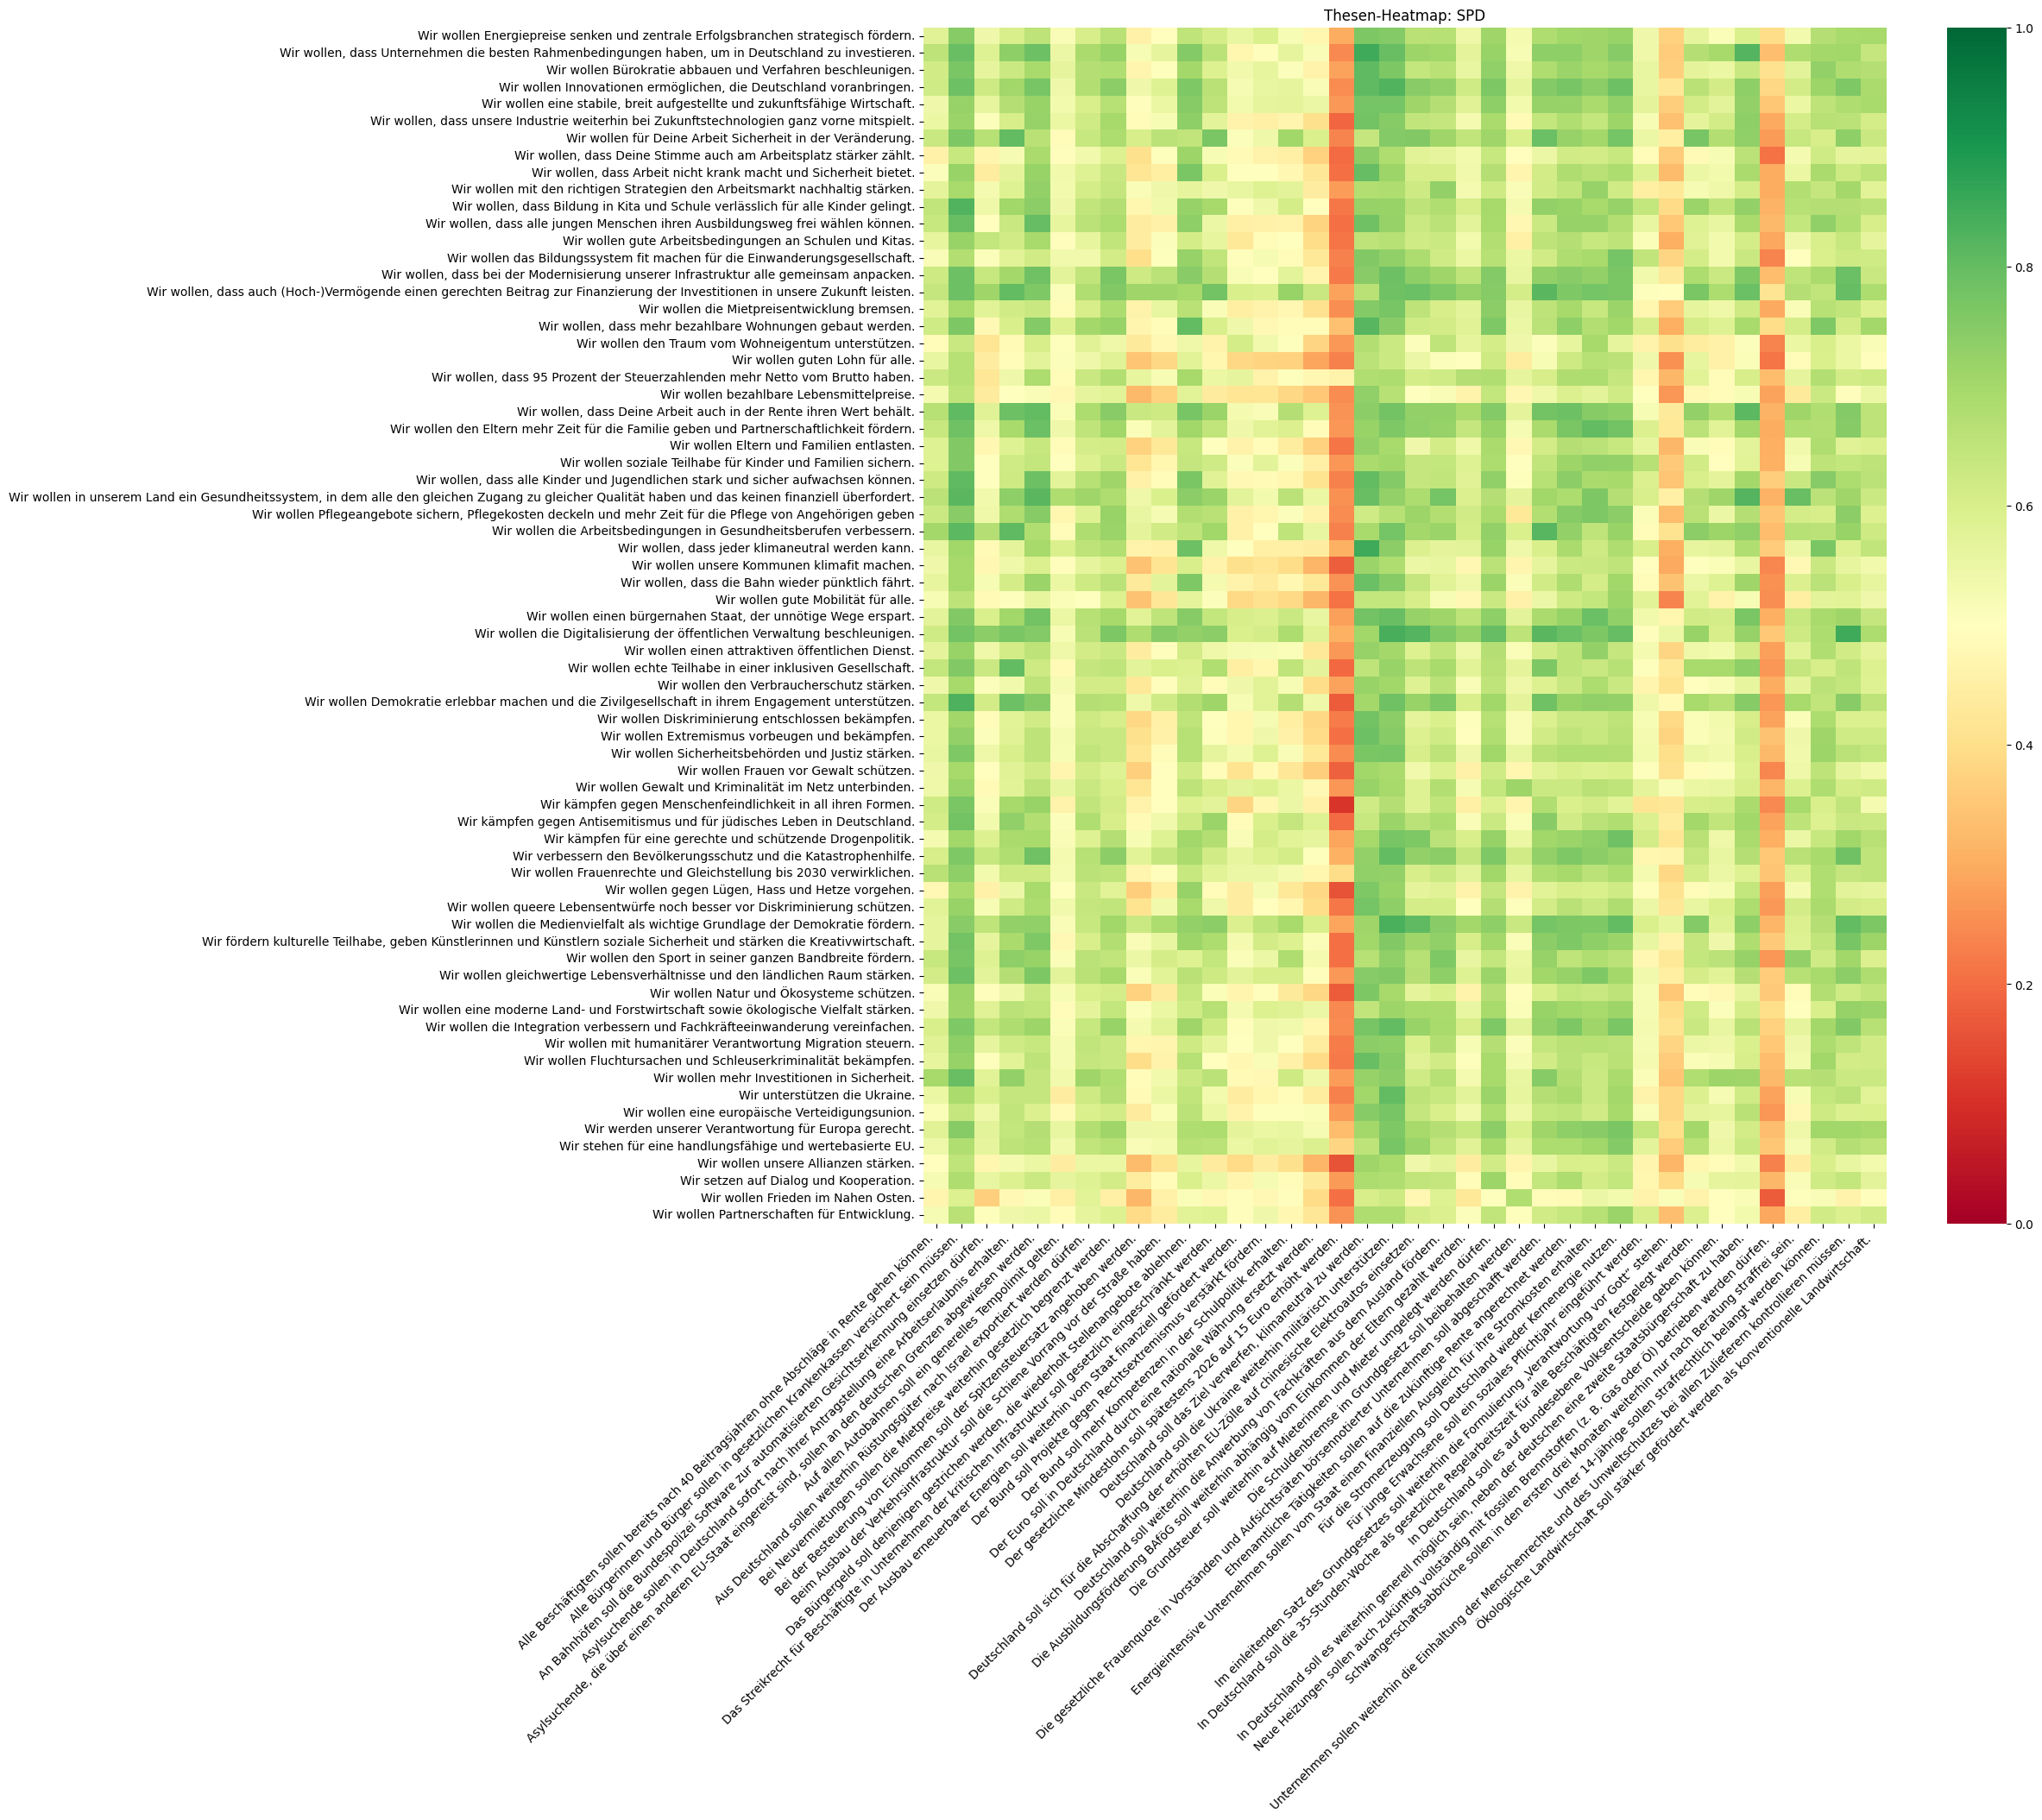

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)


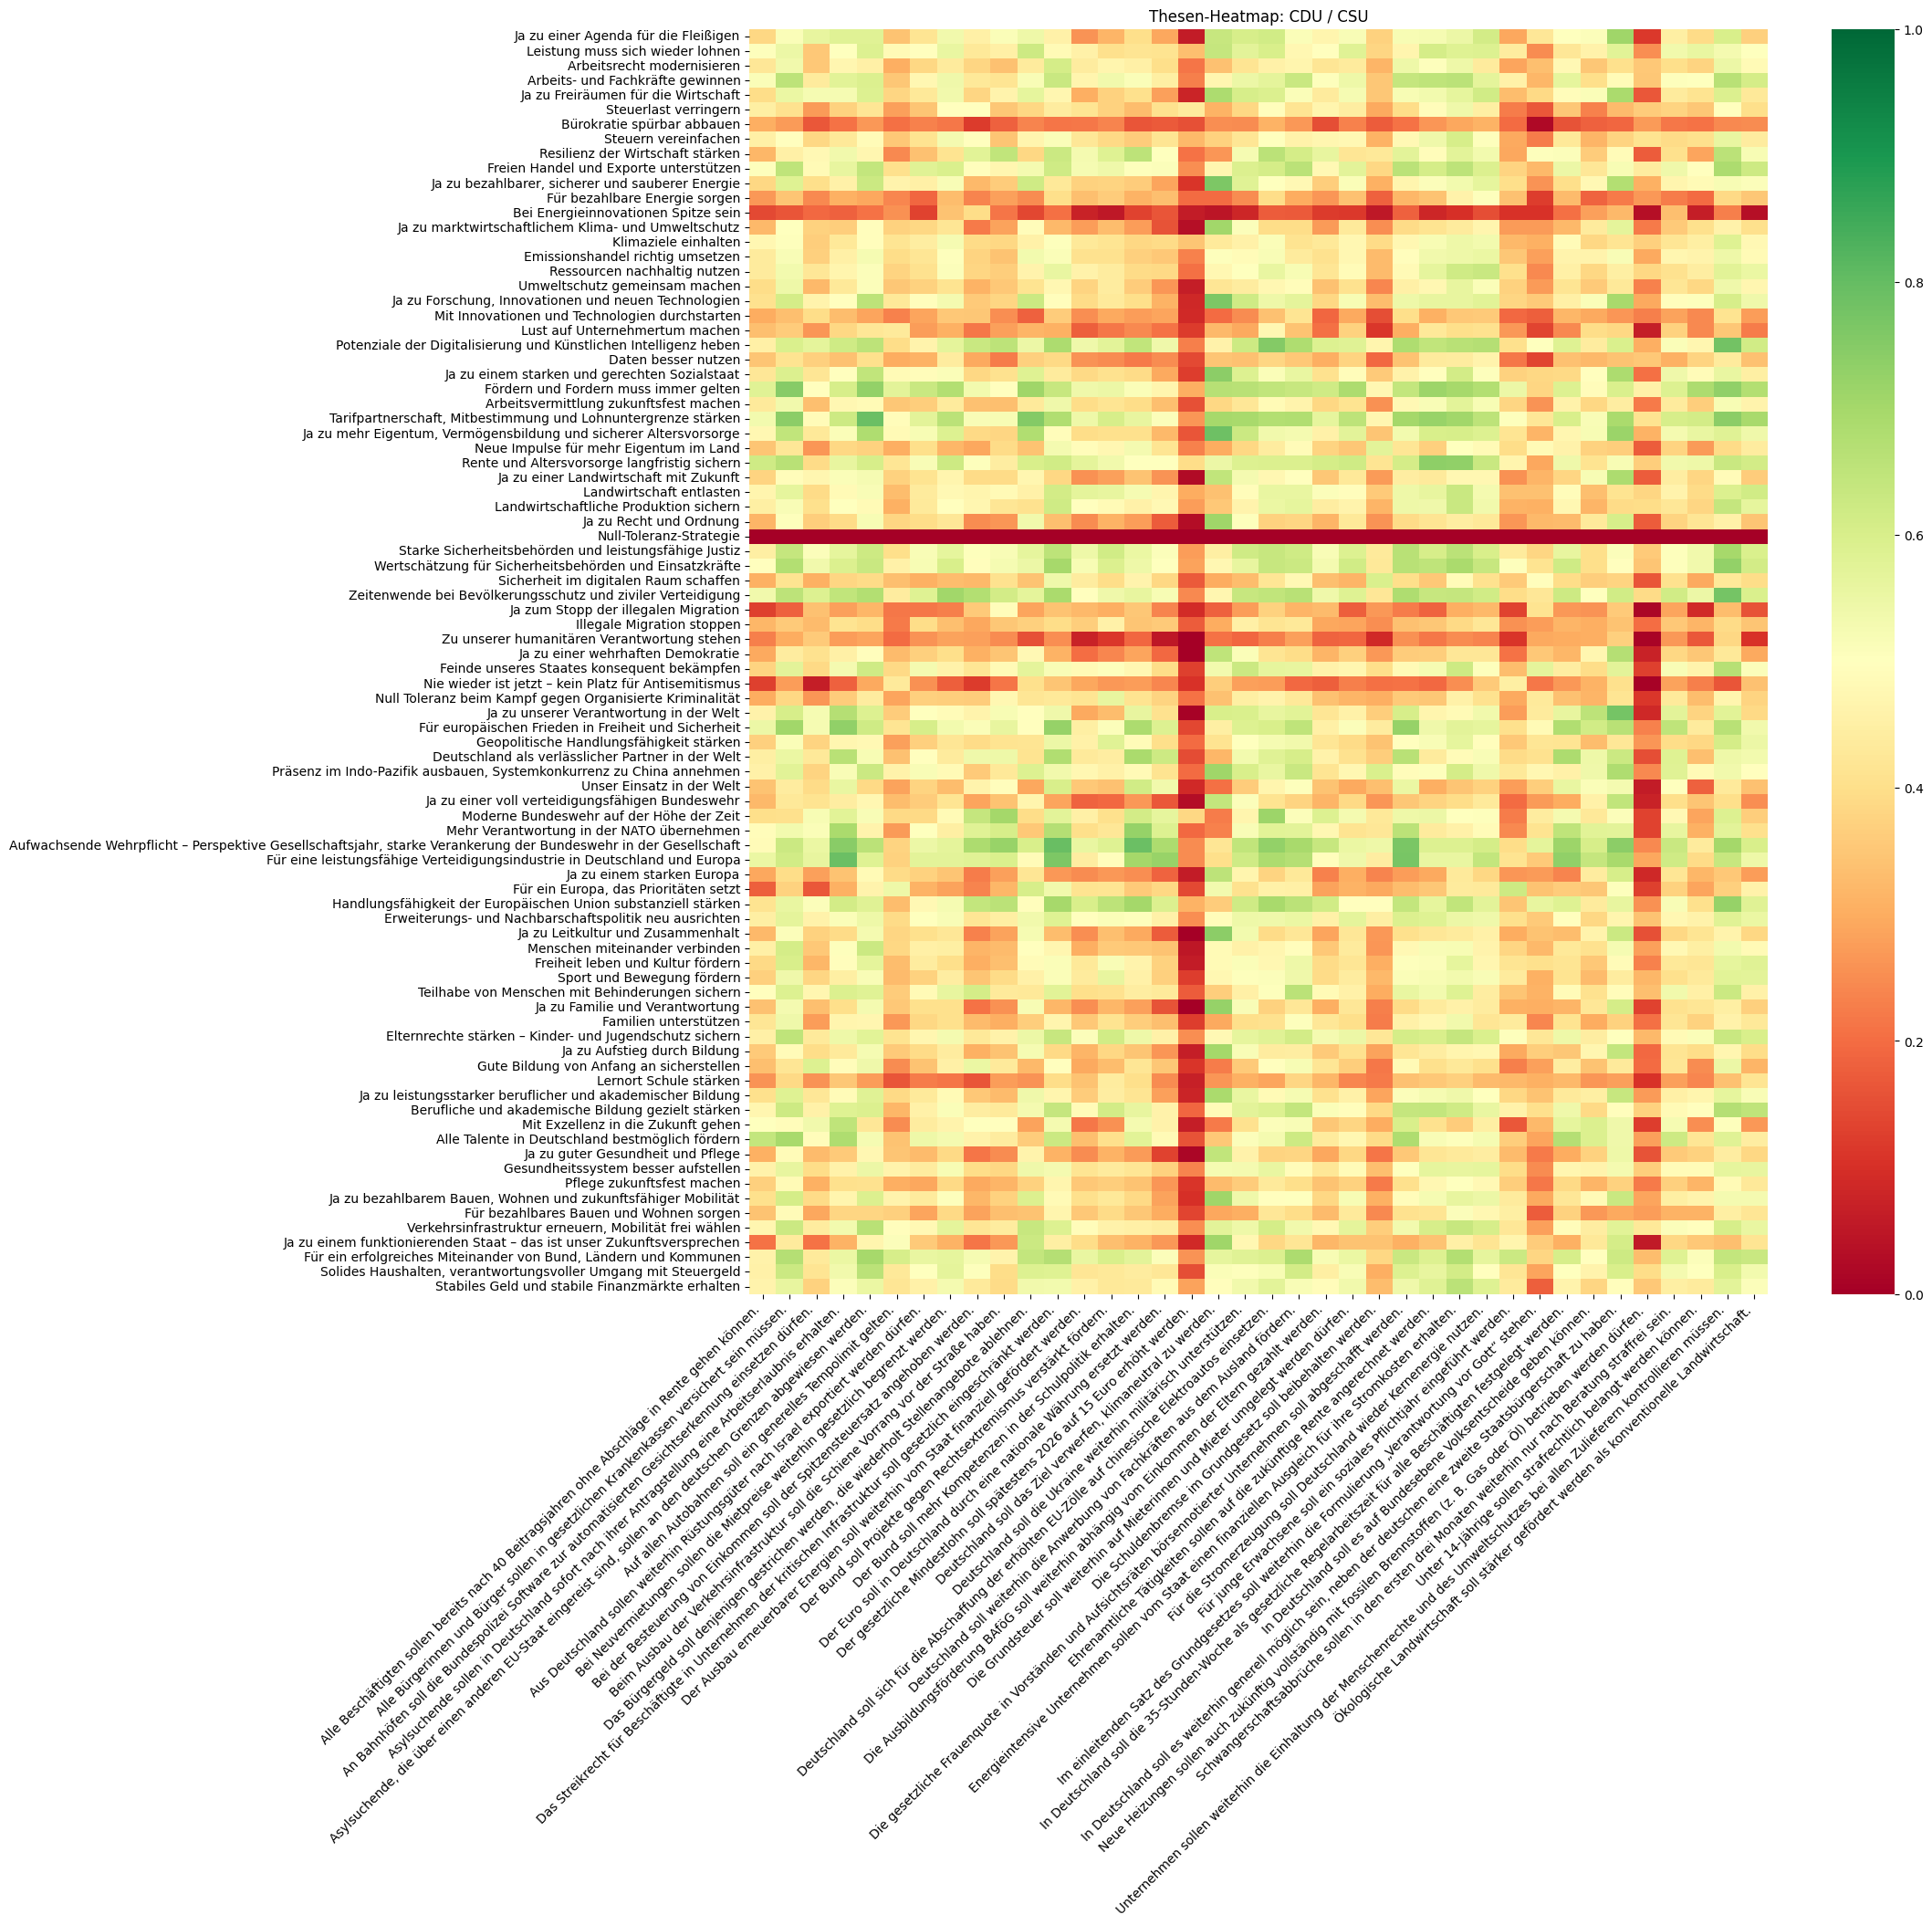

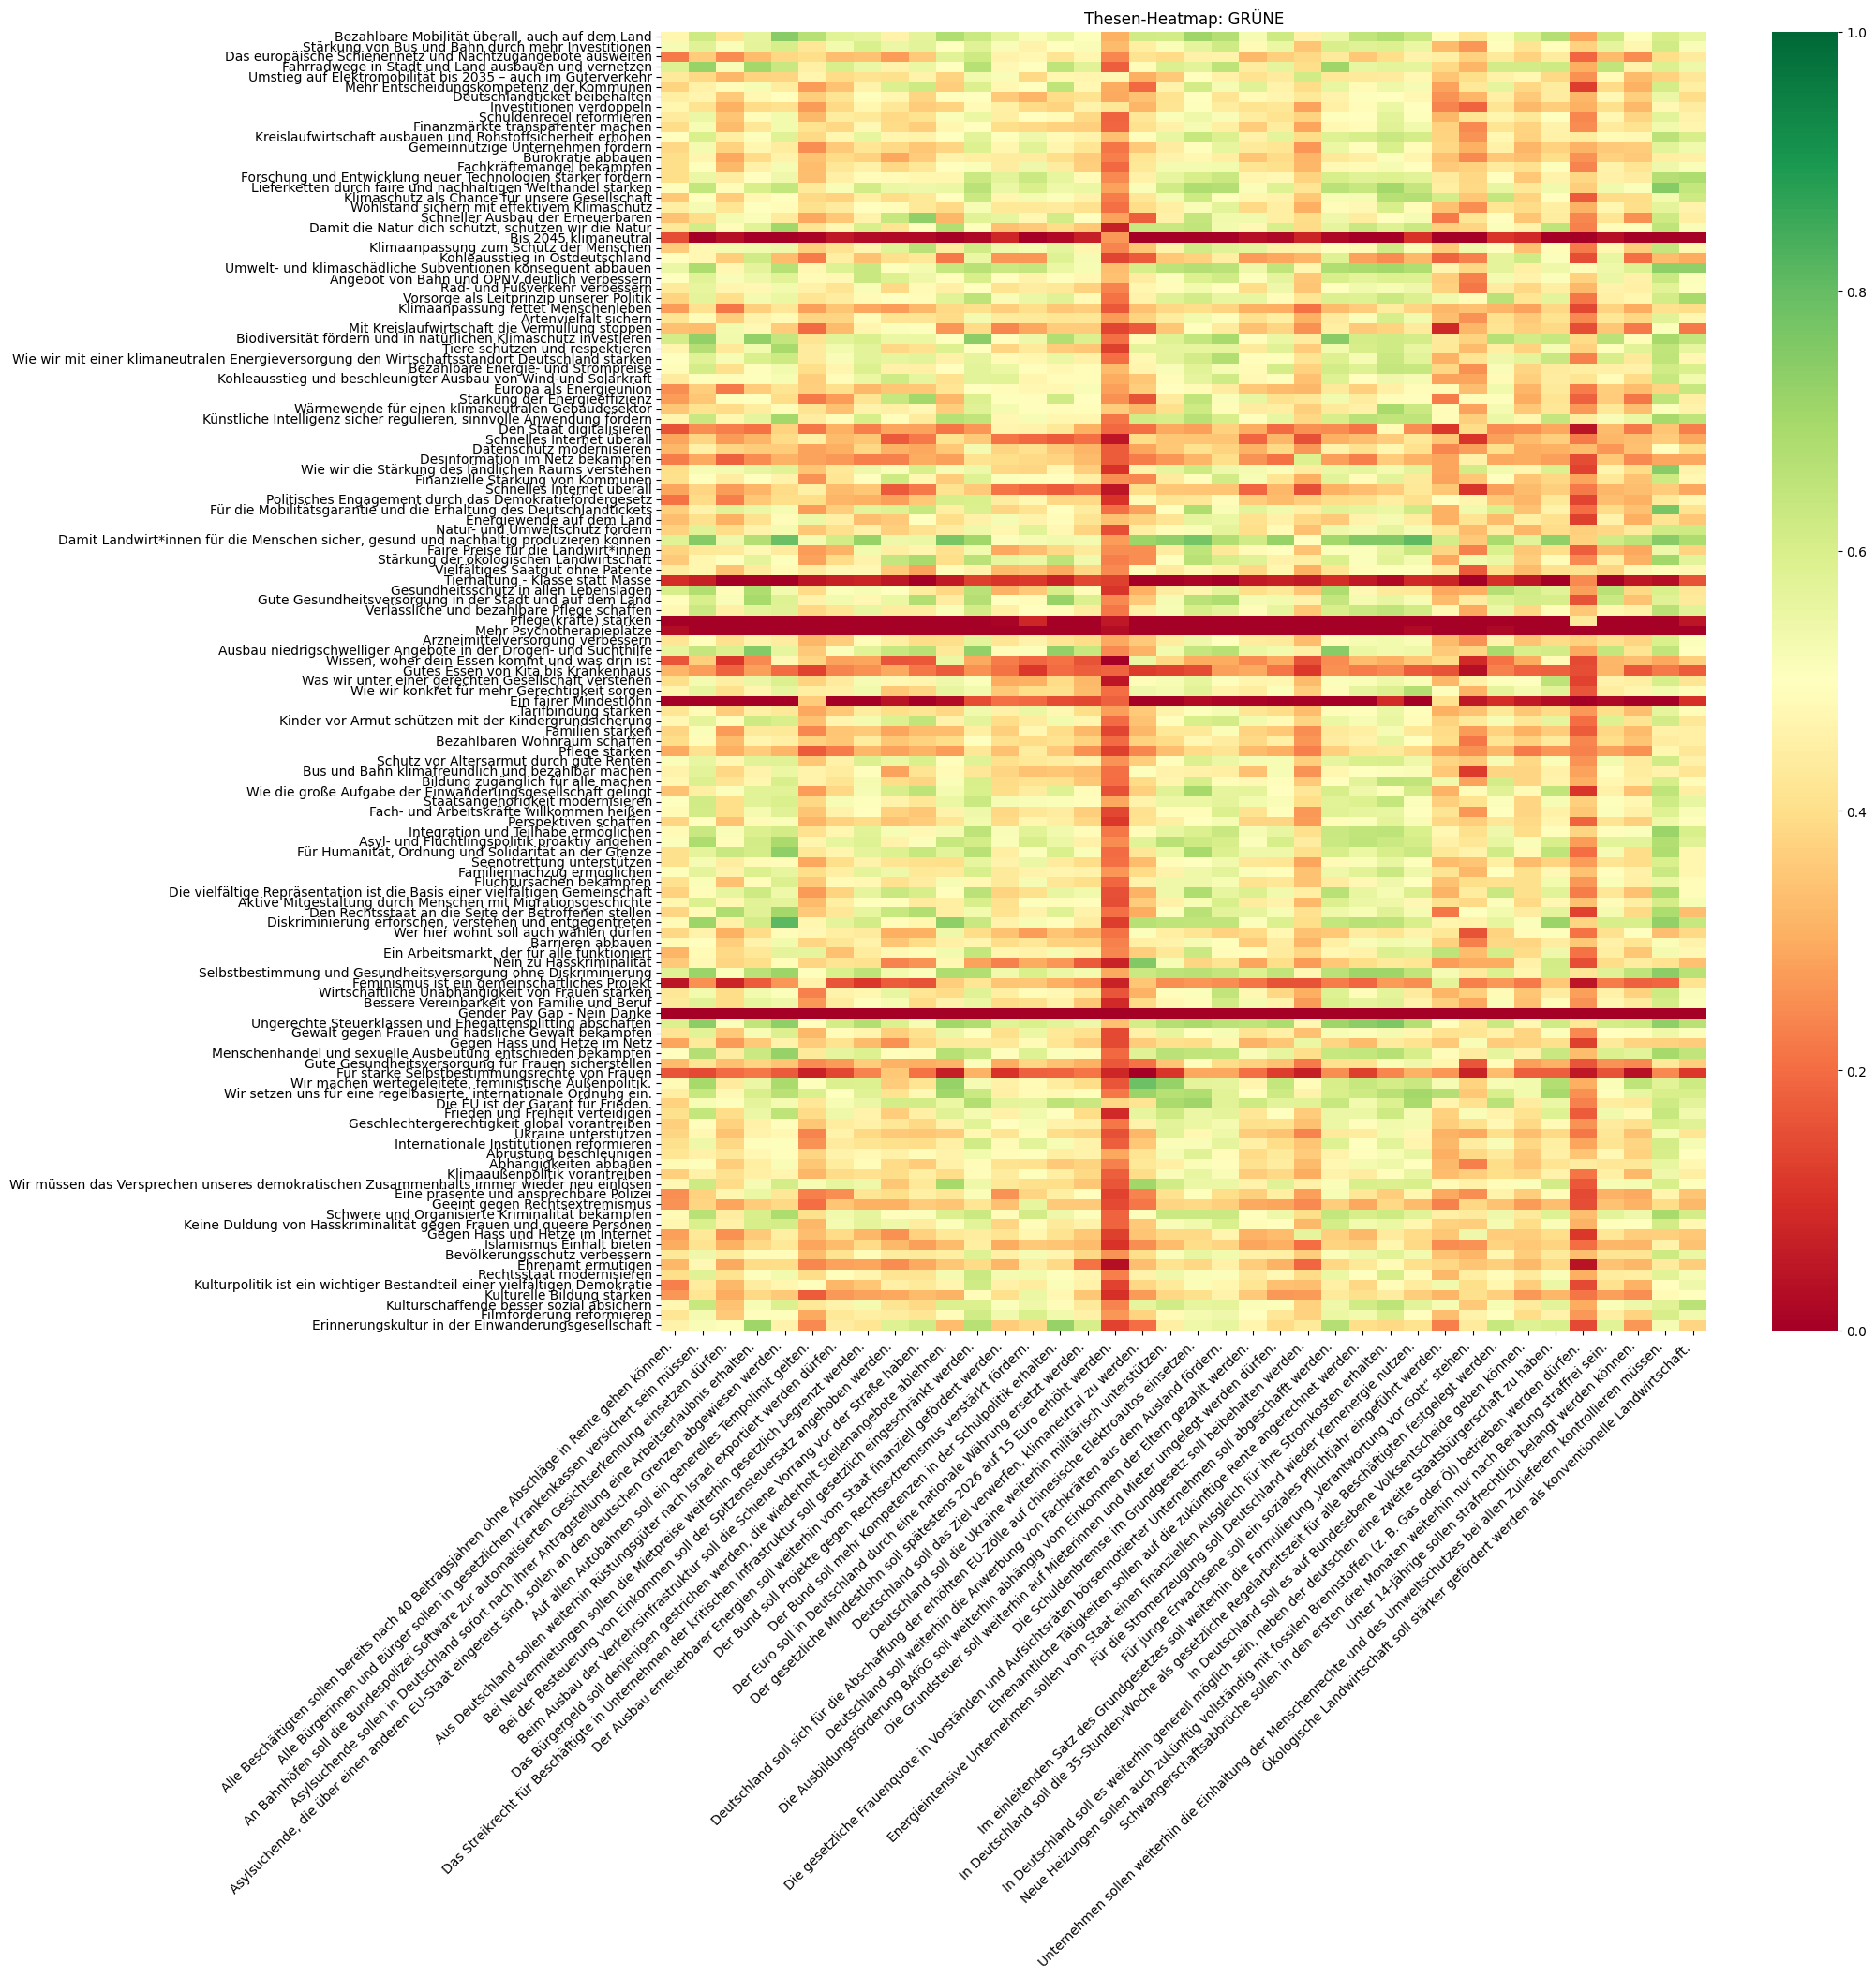

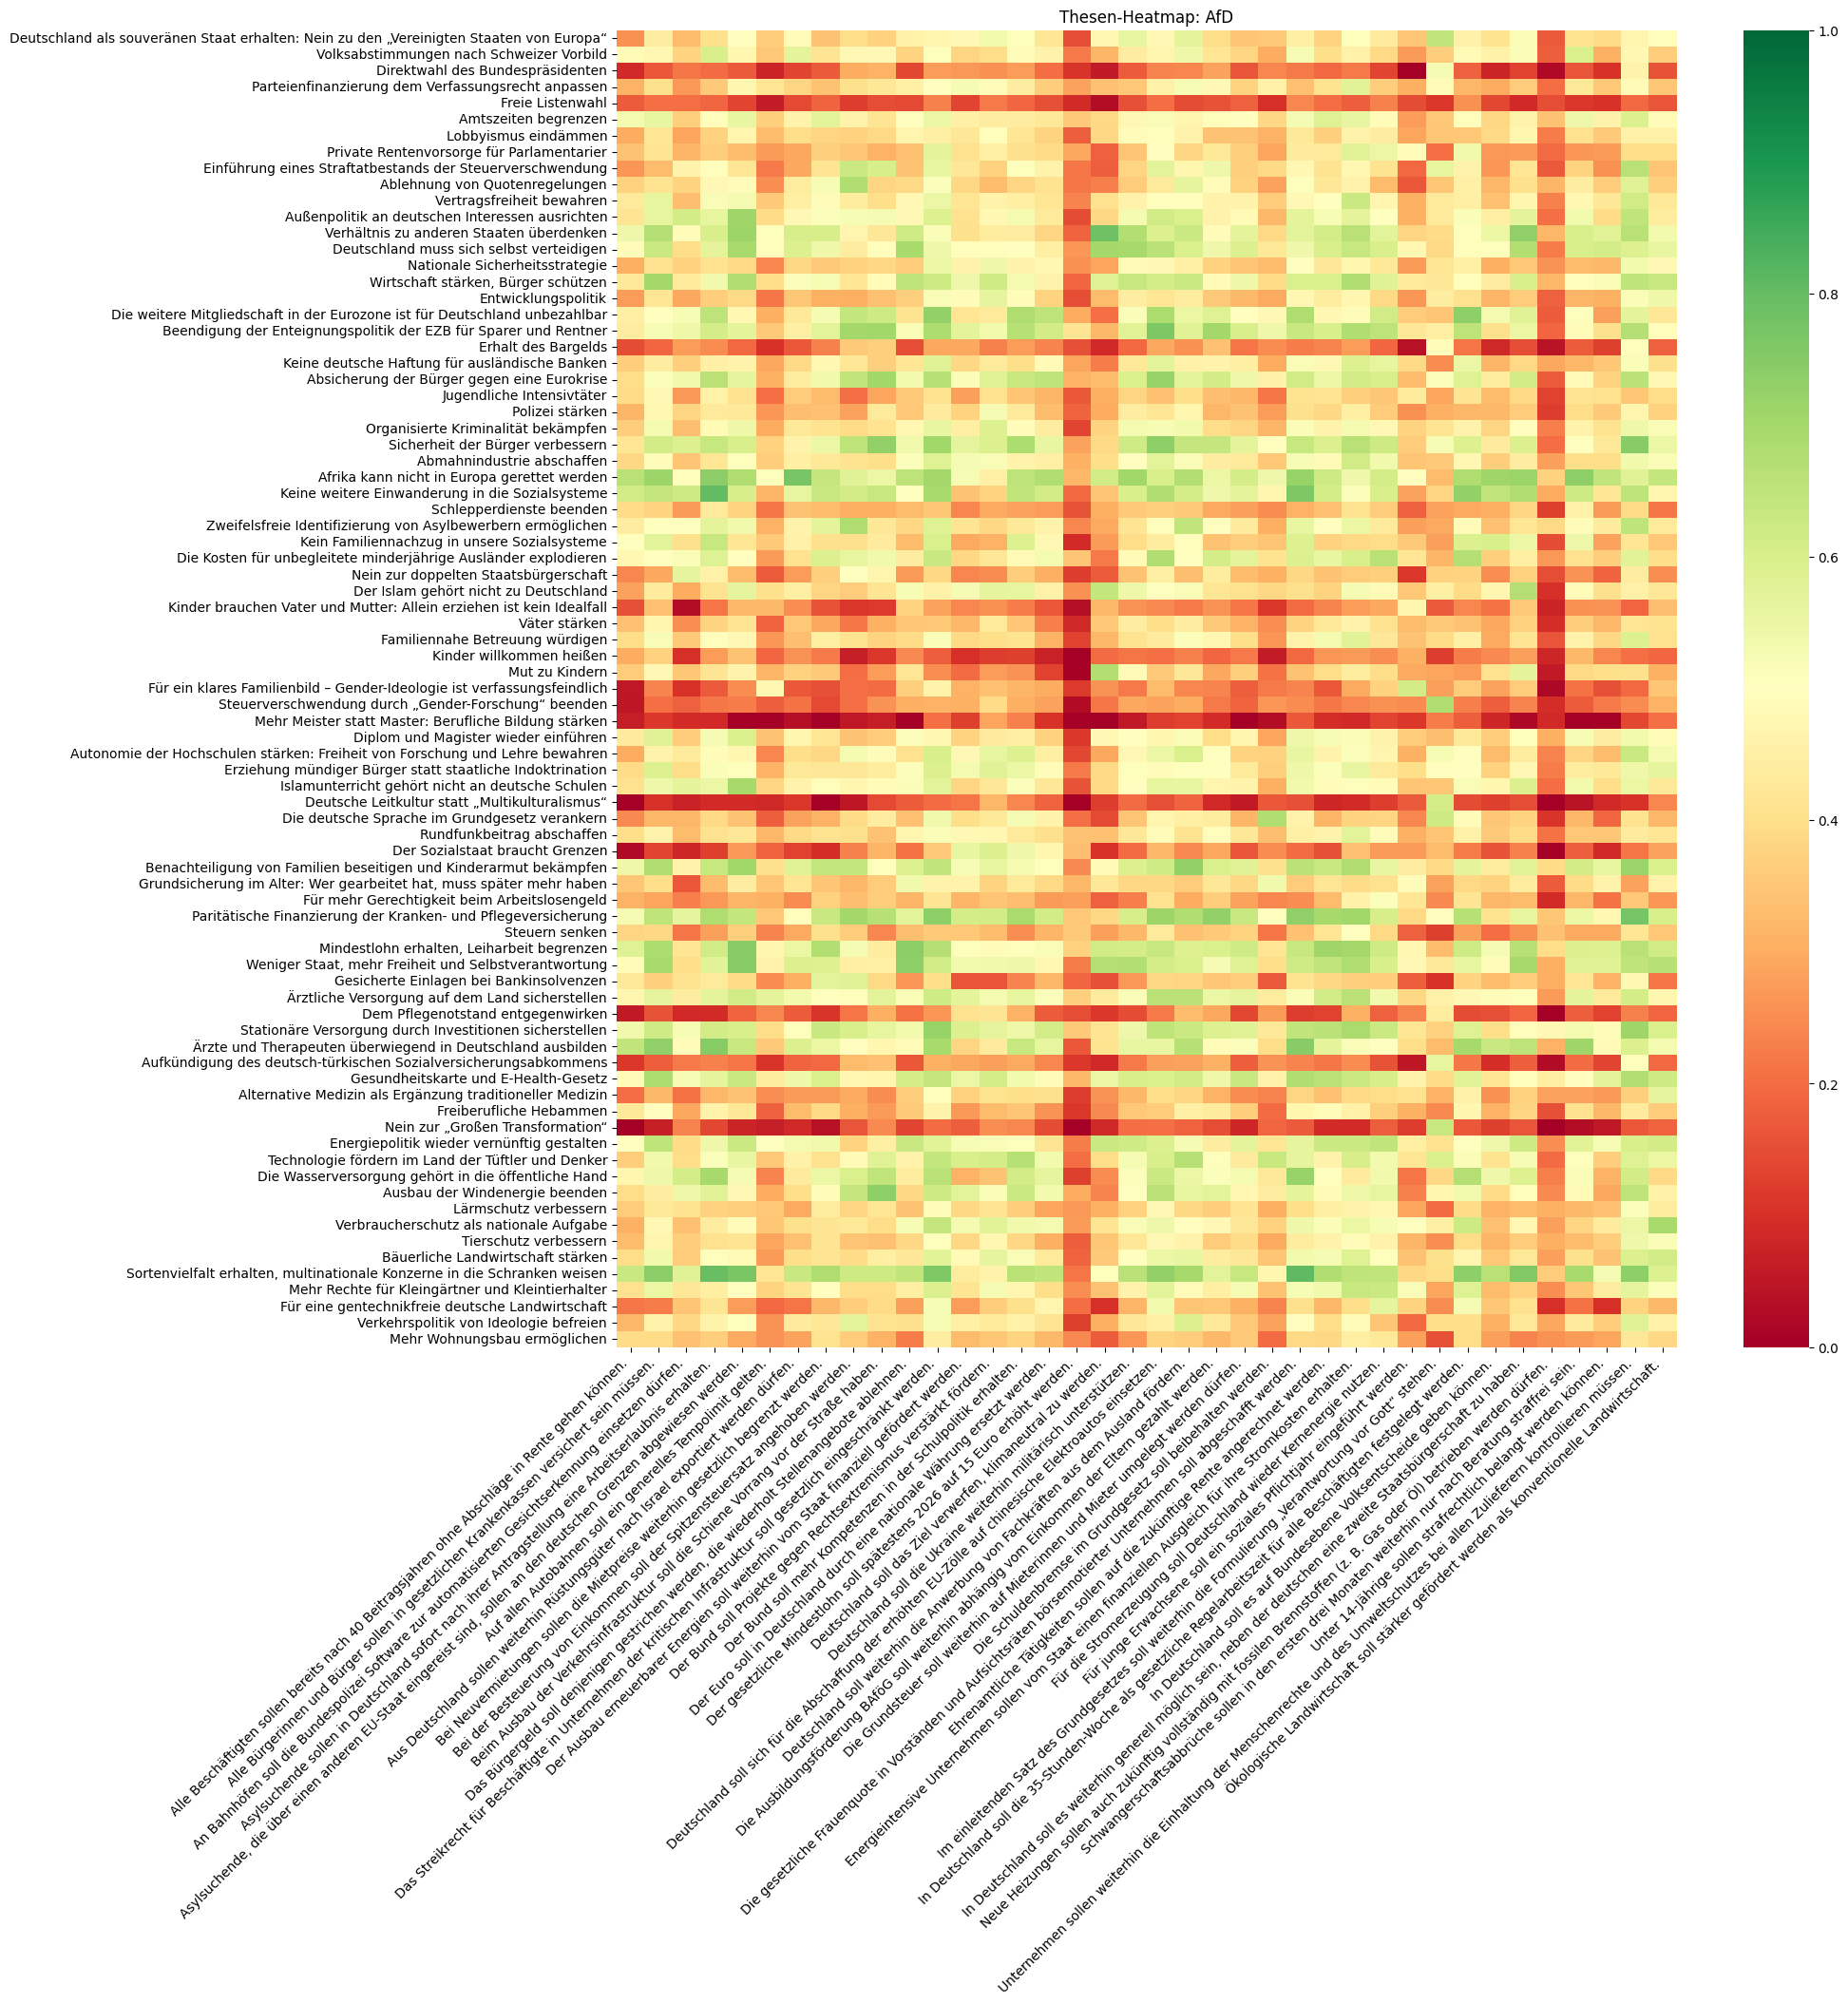

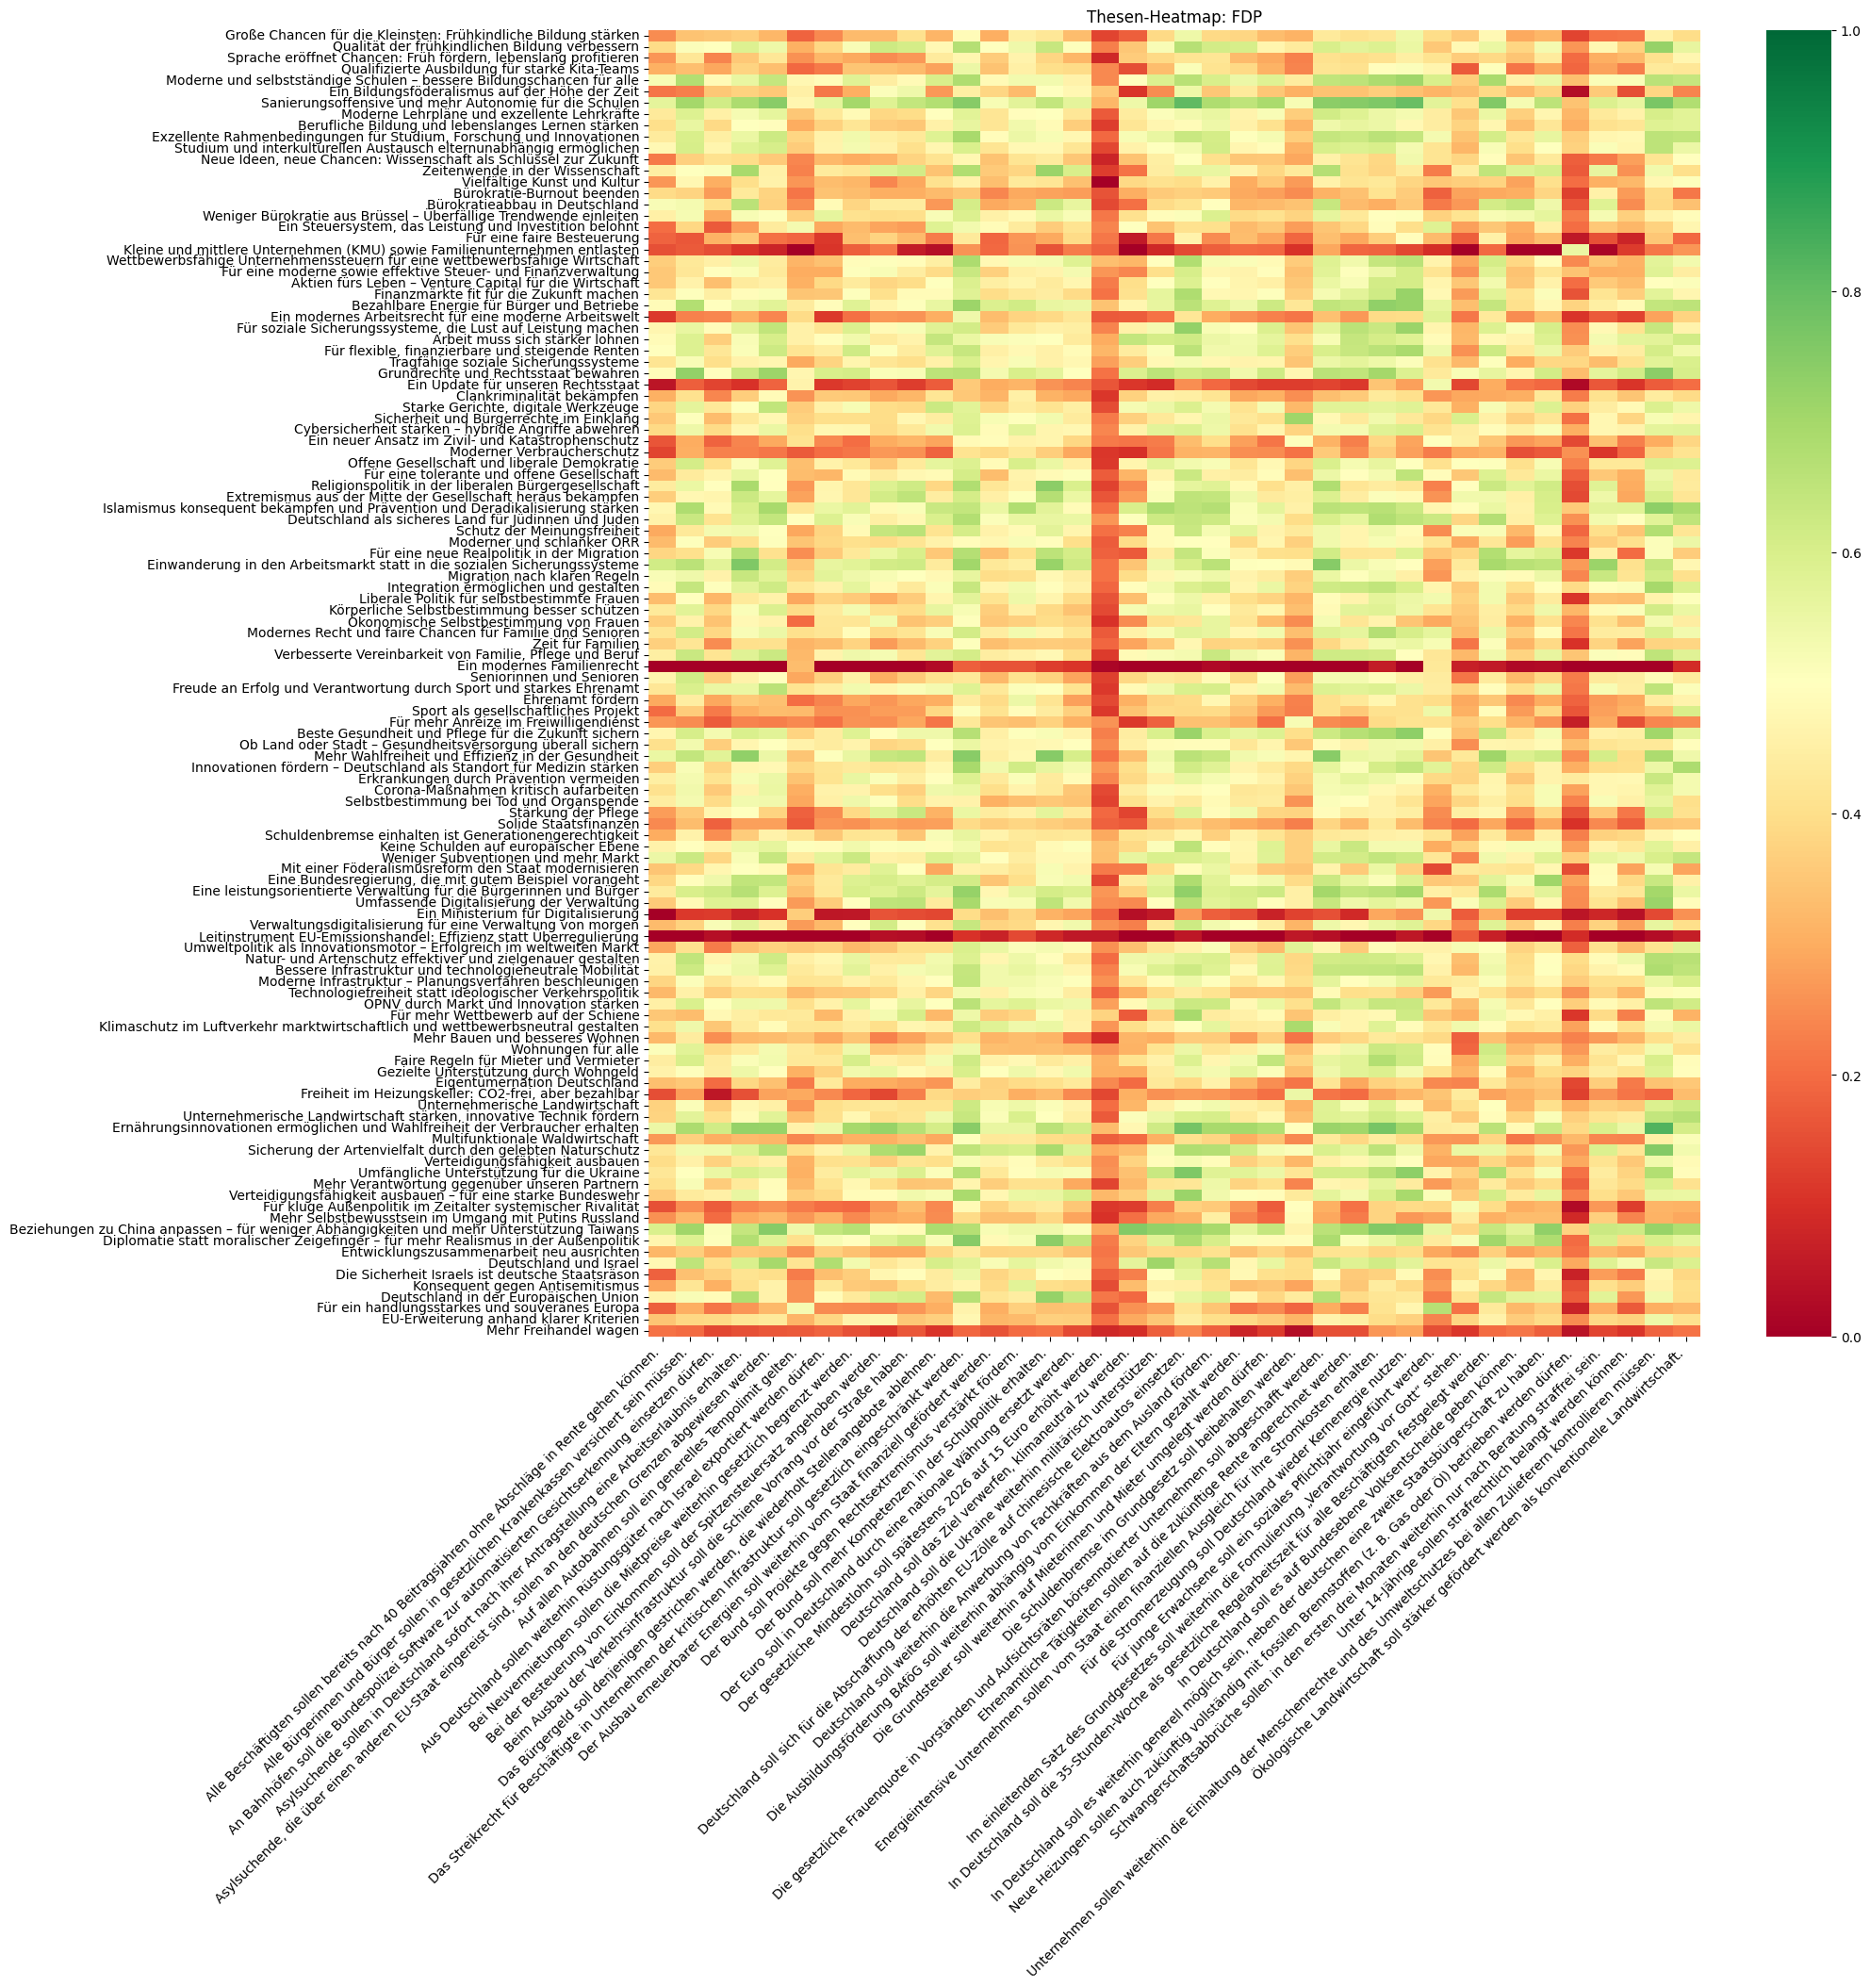

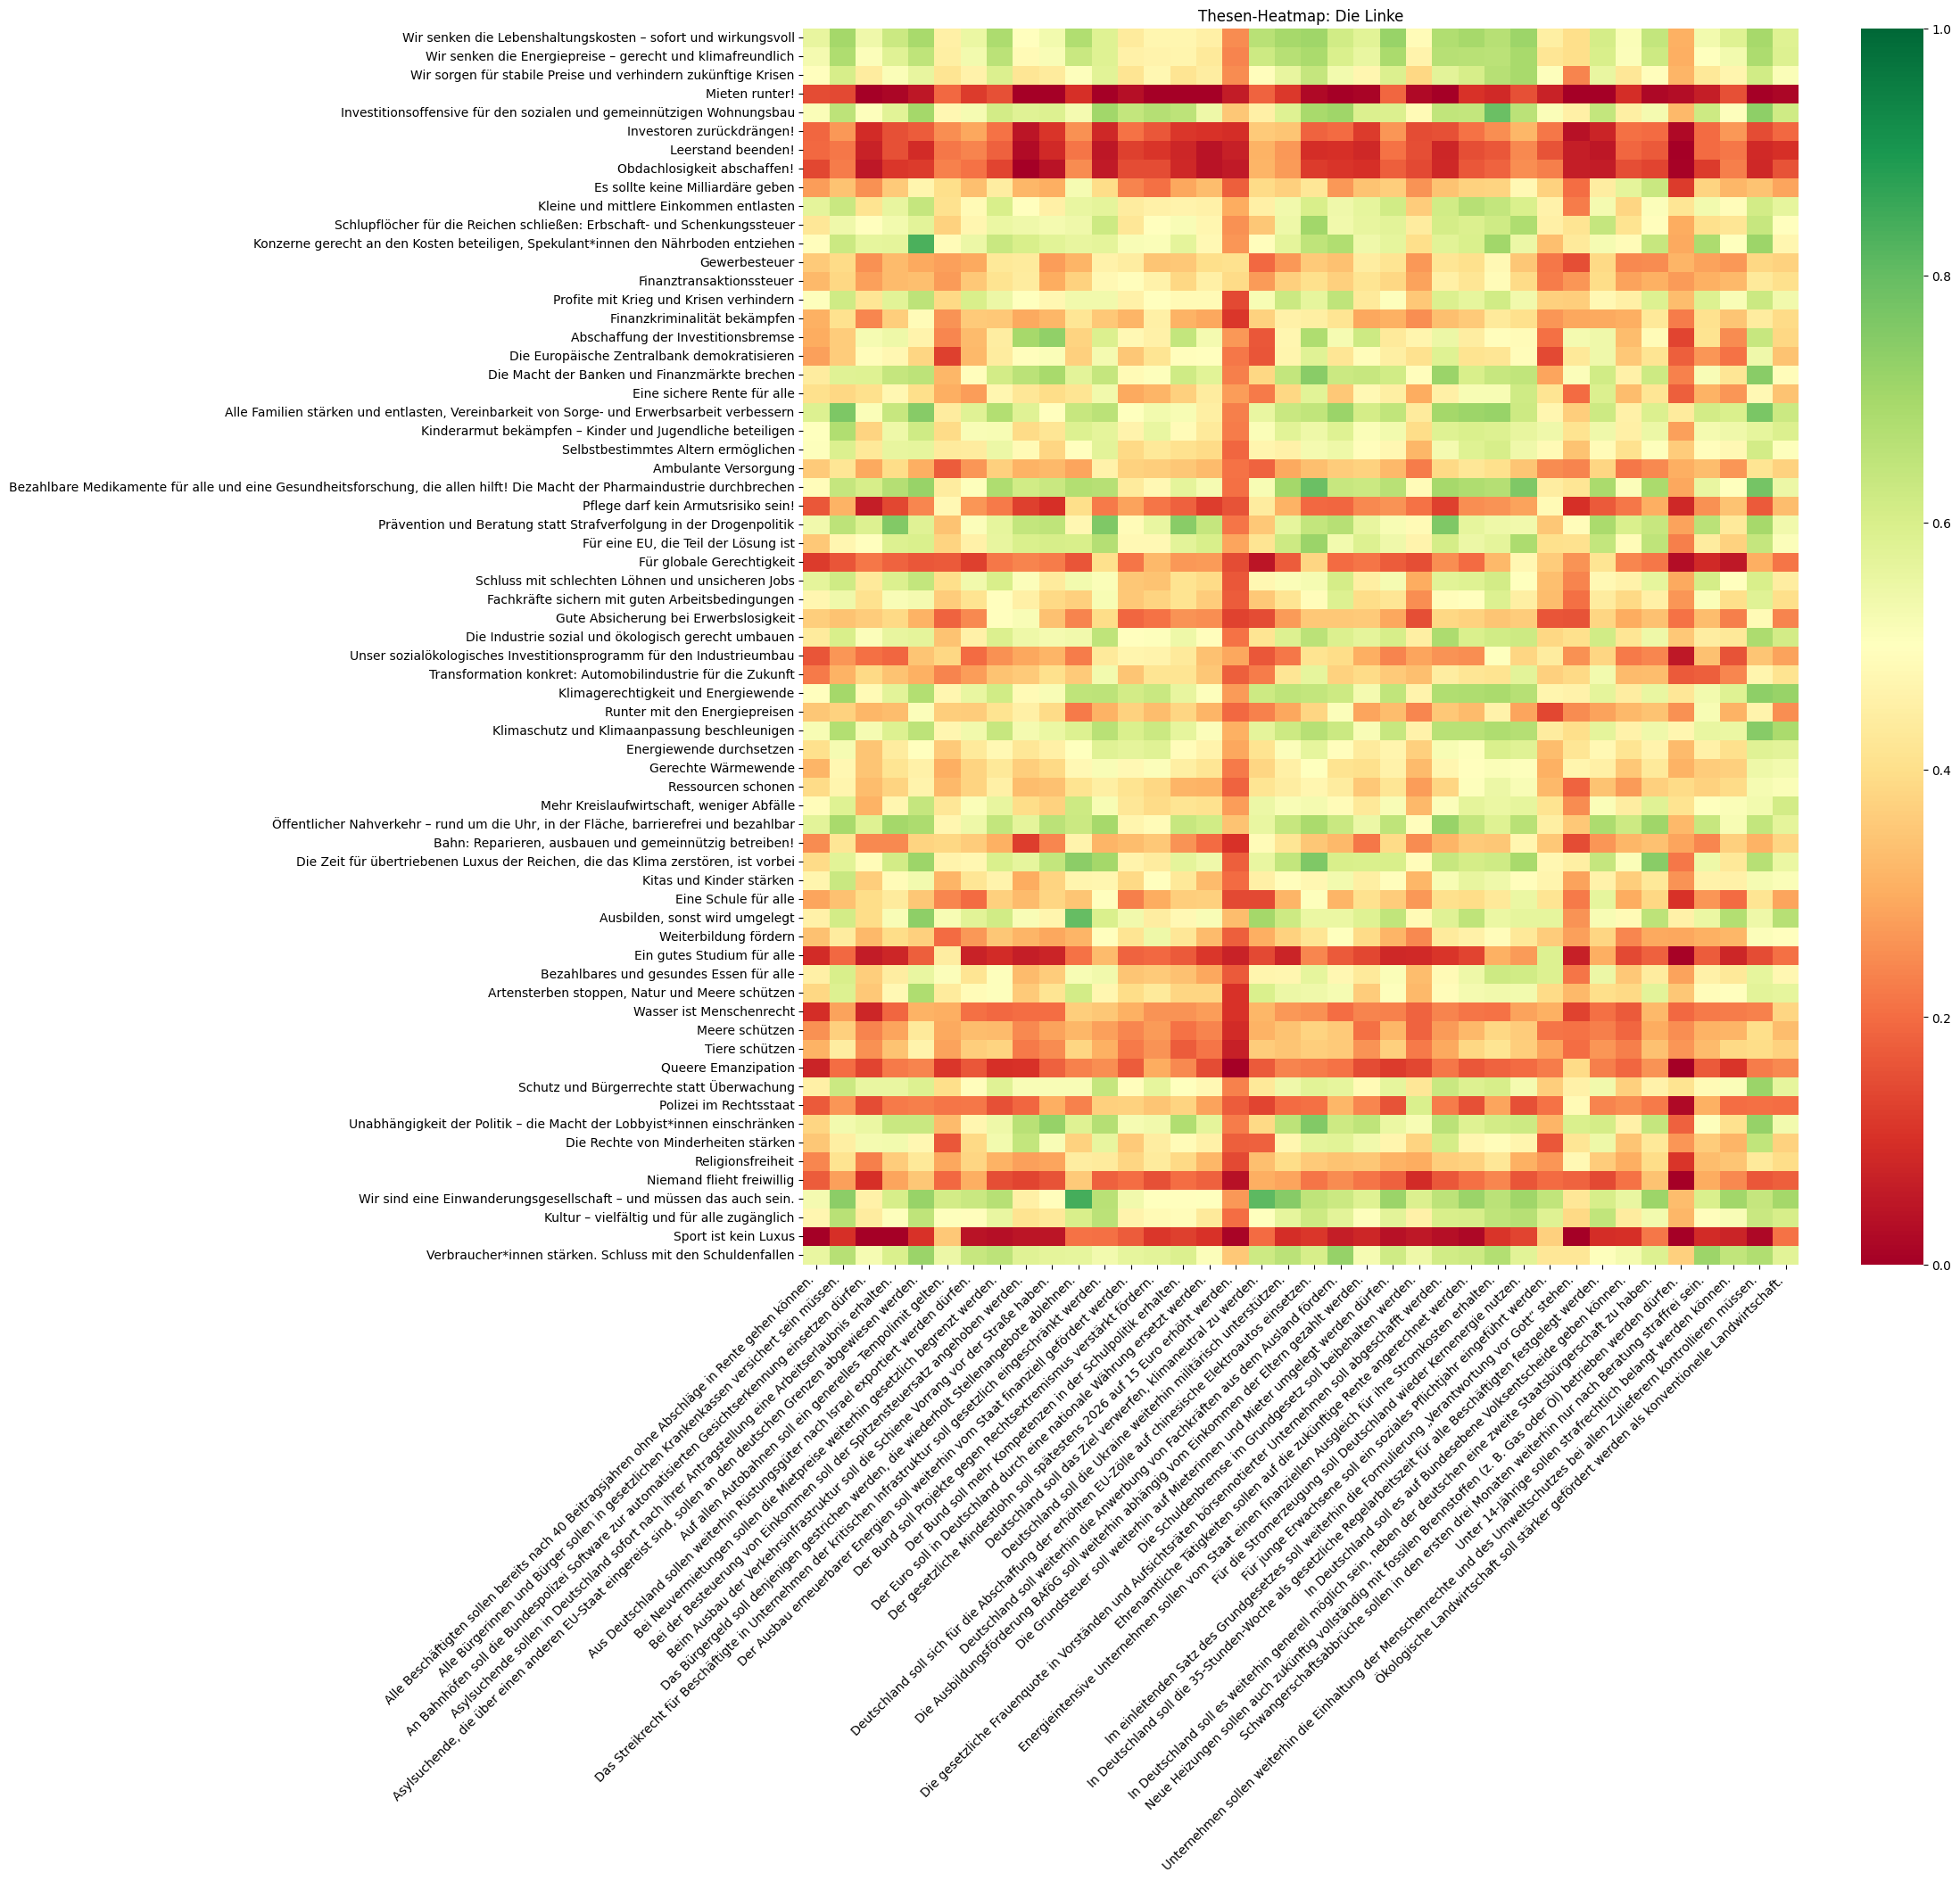

In [8]:
predicted_theses_dfs_dict, predicted_theses_df = spacy_similarity_score_func(all_party_textes_df, labled_theses_df, 'These', 'These',  plot=True)


# Modeldurchlauf mit Wahlomat Thesen und Partei Thesen

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_cla

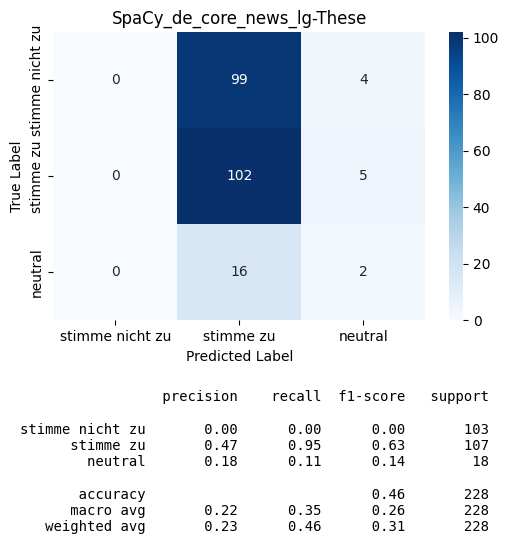

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)


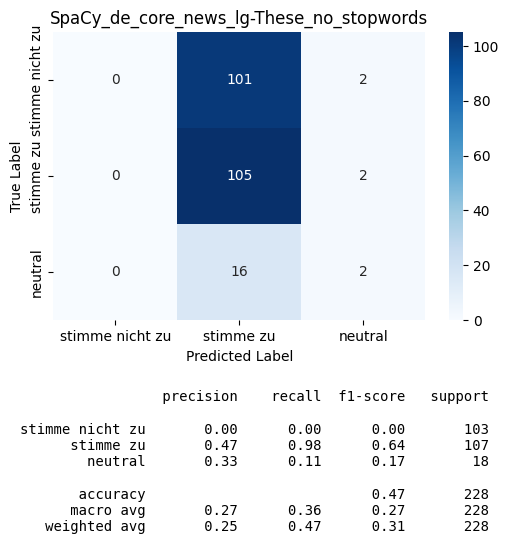

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

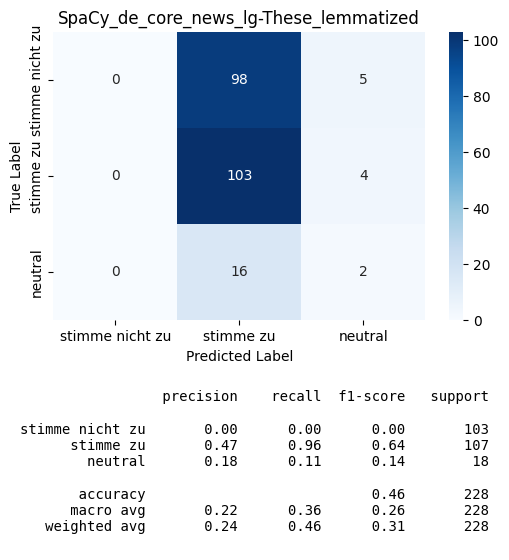

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\755588878.py:26: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_text_doc.similarity(label_text_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

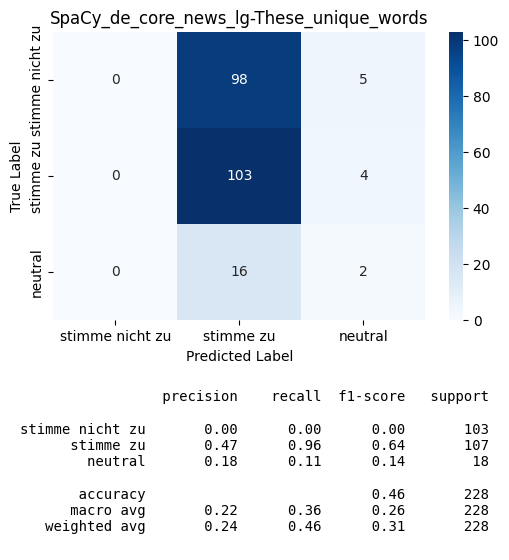

In [9]:
import os
import pickle

folder_path = r'SpaCy_Prediction_Data\These'
party_text_columns_list = ['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words']
lable_text_columns_list = ['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words']

lable_list = ["stimme nicht zu", "neutral", "stimme zu"]
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']


Model_prediction_scores = pd.DataFrame(columns= ['model', 'lable_text_column', 'party_text_column' ,'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1'])


for text_List_idx, text_column in enumerate(lable_text_columns_list):
    
    lable_text_column = text_column
    party_text_column = party_text_columns_list[text_List_idx]
    predicted_theses_dfs_dict, predicted_theses_df = spacy_similarity_score_func(all_party_textes_df,
                                                                     labled_theses_df,
                                                                     lable_text_column,
                                                                     party_text_column, 
                                                                     plot=False) 
                                                                     
    folder_path_file = os.path.join(folder_path, 'SpaCy_'+model_name, text_column)
    os.makedirs(folder_path_file, exist_ok=True)
    with open(os.path.join(folder_path_file, 'predicted_theses_dfs_dict.pkl'), 'wb') as f:
        pickle.dump(predicted_theses_dfs_dict, f)
    with open(os.path.join(folder_path_file, 'predicted_theses_df.pkl'), 'wb') as f:
        pickle.dump(predicted_theses_df, f)
    #Mapping des predicted theses dfs
    predicted_theses_df_mapped = mapping_similarity_to_class_func(predicted_theses_df, lable_list)
    #Apply Metric to evaluate Predictions
    scores_list = prediction_metric_func(predicted_theses_df_mapped, labled_theses_df, parties_list, plot=True, plot_title=f'{'SpaCy_'+model_name}-{text_column}')
    #Save Metrics in df to compare
    Model_prediction_scores.loc[len(Model_prediction_scores)] = ['SpaCy_'+model_name, lable_text_column, party_text_column, False ]+scores_list
    
    
            
with open(os.path.join(folder_path, 'Model_prediction_scores.pkl'), 'wb') as f:
    pickle.dump(Model_prediction_scores, f)

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

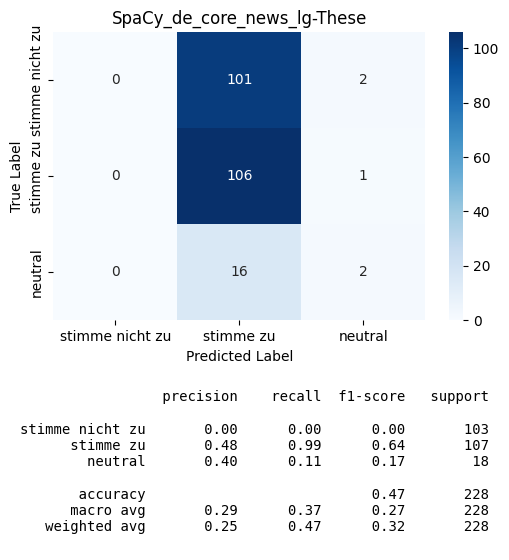

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

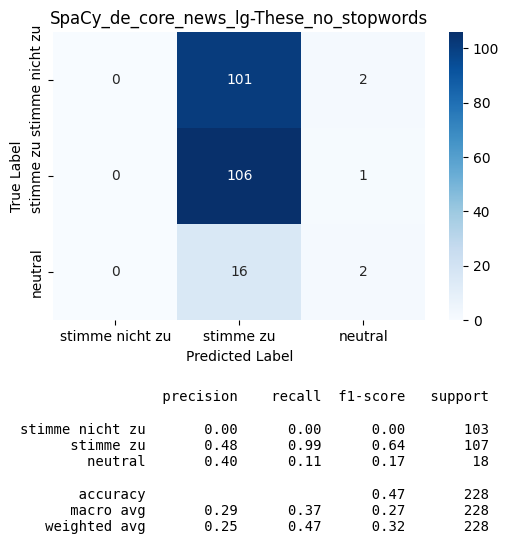

C:\Users\lnieb\AppData\Local\Temp\ipykernel_30620\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

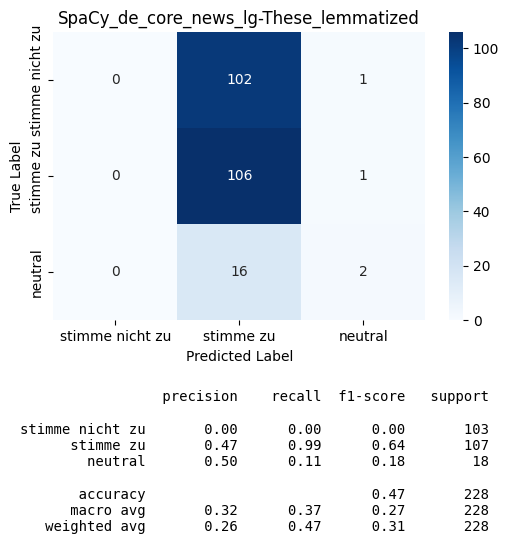

In [10]:
folder_path = r'SpaCy_Prediction_Data\Text'
party_text_columns_list = ['Text',  'Text_no_stopwords',  'Text_lemmatized']
lable_text_columns_list = ['These', 'These_no_stopwords', 'These_lemmatized']

lable_list = ["stimme nicht zu", "neutral", "stimme zu"]
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']


Model_prediction_scores = pd.DataFrame(columns= ['model', 'lable_text_column', 'party_text_column' ,'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1'])

for text_List_idx, text_column in enumerate(lable_text_columns_list):
    
    lable_text_column = text_column
    party_text_column = party_text_columns_list[text_List_idx]
    predicted_theses_dfs_dict, predicted_theses_df = spacy_similarity_score_func(all_party_textes_df,
                                                                     labled_theses_df,
                                                                     lable_text_column,
                                                                     party_text_column, 
                                                                     plot=False) 
                                                                     
    folder_path_file = os.path.join(folder_path, 'SpaCy_'+model_name, text_column)
    os.makedirs(folder_path_file, exist_ok=True)
    with open(os.path.join(folder_path_file, 'predicted_theses_dfs_dict.pkl'), 'wb') as f:
        pickle.dump(predicted_theses_dfs_dict, f)
    with open(os.path.join(folder_path_file, 'predicted_theses_df.pkl'), 'wb') as f:
        pickle.dump(predicted_theses_df, f)
    #Mapping des predicted theses dfs
    predicted_theses_df_mapped = mapping_similarity_to_class_func(predicted_theses_df, lable_list)
    #Apply Metric to evaluate Predictions
    scores_list = prediction_metric_func(predicted_theses_df_mapped, labled_theses_df, parties_list, plot=True, plot_title=f'{'SpaCy_'+model_name}-{text_column}')
    #Save Metrics in df to compare
    Model_prediction_scores.loc[len(Model_prediction_scores)] = ['SpaCy_'+model_name, lable_text_column, party_text_column, False ]+scores_list
            
with open(os.path.join(folder_path, 'Model_prediction_scores.pkl'), 'wb') as f:
    pickle.dump(Model_prediction_scores, f)